# Statistical Models for Classification - Part 2

> Part 1 of this lab -> 07-ScikitLearn-Classification.pptx

This notebook is a short introduction to logistic regression with `statsmodels`.
We will work with a toy dataset inspired by the Titanic story.

The goals of this lab are:

- understand binary classification with logistic regression
- interpret coefficients in simple terms
- compute and interpret odds ratios
- plot the logistic curve
- visualize uncertainty with confidence intervals
- understand multicollinearity
- use VIF to detect redundant predictors




## Structure of the lab

- Part 1. import and inspect a toy dataset
- Part 2. Fit a logistic regression with one predictor
- Part 3. Plot the probability curve and confidence interval
- Part 4. Interpret the separation point
- Part 5. Add more predictors
- Part 6. Study multicollinearity with VIF
- Part 7. Compare models and discuss interpretation
- Part 8. Final exercises


In [4]:
pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.special import expit

np.random.seed(42)


## Part 1. Import and inspect a toy dataset


In [7]:
import seaborn as sns

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### First look

Before fitting a model, it is always useful to inspect the data.
We start with a scatter plot of `fare` against the binary target.

Because the target is binary, points will appear only at 0 and 1.
Still, the plot helps us see whether larger values of `fare` tend to be associated with survival.


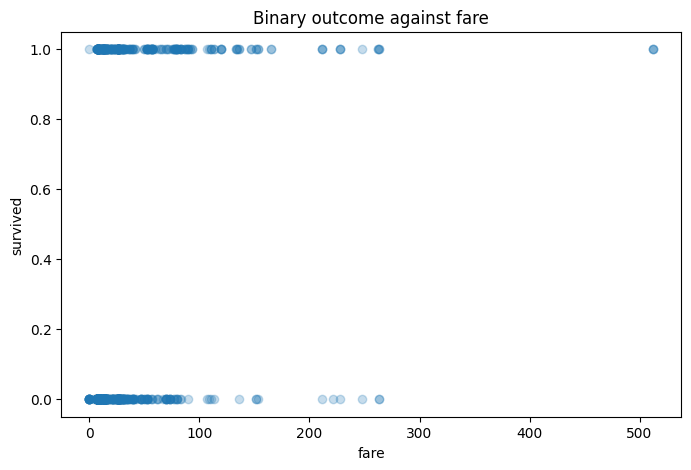

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['fare'], df['survived'], alpha=0.25)
plt.xlabel('fare')
plt.ylabel('survived')
plt.title('Binary outcome against fare')
plt.show()


<Axes: xlabel='survived', ylabel='fare'>

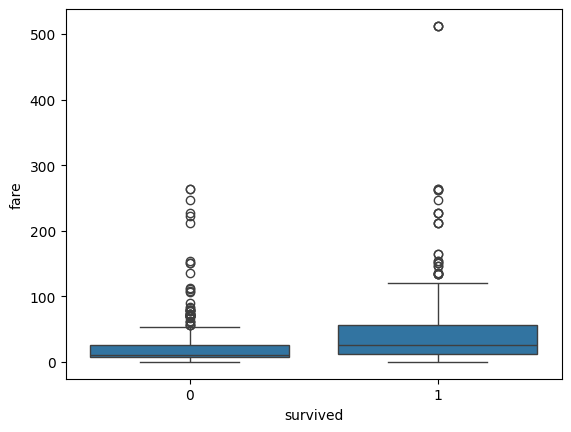

In [11]:
sns.boxplot(x='survived', y='fare', data=df)

## Part 2. Logistic regression with one predictor

Logistic regression is used when the target is binary.

Instead of predicting any real number, it predicts a probability between 0 and 1.

The model is:

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$

This means:
- the model first computes a linear combination
- then it transforms it with the logistic function
- the output is a probability

We begin with a simple model:

$$\text{survived} \sim \text{fare}$$

This is useful because it is easy to visualize.


In [12]:
model_1 = smf.logit('survived ~ fare', data=df).fit()
print(model_1.summary())


Optimization terminated successfully.
         Current function value: 0.627143
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      889
Method:                           MLE   Df Model:                            1
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.05822
Time:                        10:22:49   Log-Likelihood:                -558.78
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 9.427e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9413      0.095     -9.895      0.000      -1.128      -0.755
fare           0.0152      0.

### How to read the summary

Important parts of the output:

- `coef`: estimated coefficients
- `std err`: standard error of each coefficient
- `z`: test statistic
- `P>|z|`: p-value -> **must be lower than a threshold (e.g. 0.05) to reject the null hypothesis of zero effect**
- `[0.025, 0.975]`: 95% confidence interval for the coefficient

If the coefficient of `fare` is positive, higher fare is associated with higher probability of survival.

If the p-value is small, we have evidence that the effect is not zero in this model.


In [13]:
odds_ratios_1 = np.exp(model_1.params)
odds_ratios_1


Intercept    0.390109
fare         1.015313
dtype: float64

### Odds ratios

The coefficients of logistic regression are expressed in log-odds units.
This is not always easy to interpret.

A common trick is to exponentiate the coefficients:

$$\text{odds ratio} = e^{\beta}$$

Interpretation:
- if the odds ratio is greater than 1, increasing the predictor increases the odds of survival
- if the odds ratio is smaller than 1, increasing the predictor decreases the odds


>For example, if the odds ratio for `fare` is 1.07, then a one-unit increase in fare multiplies the odds of survival by 1.07.


## Part 3. Predicted probability curve

Now we compute predicted probabilities on a grid of `fare` values.
This lets us draw the logistic curve.


In [14]:
fare_grid = np.linspace(df['fare'].min(), df['fare'].max(), 250)
fare_grid

array([  0.        ,   2.05754699,   4.11509398,   6.17264096,
         8.23018795,  10.28773494,  12.34528193,  14.40282892,
        16.4603759 ,  18.51792289,  20.57546988,  22.63301687,
        24.69056386,  26.74811084,  28.80565783,  30.86320482,
        32.92075181,  34.9782988 ,  37.03584578,  39.09339277,
        41.15093976,  43.20848675,  45.26603373,  47.32358072,
        49.38112771,  51.4386747 ,  53.49622169,  55.55376867,
        57.61131566,  59.66886265,  61.72640964,  63.78395663,
        65.84150361,  67.8990506 ,  69.95659759,  72.01414458,
        74.07169157,  76.12923855,  78.18678554,  80.24433253,
        82.30187952,  84.35942651,  86.41697349,  88.47452048,
        90.53206747,  92.58961446,  94.64716145,  96.70470843,
        98.76225542, 100.81980241, 102.8773494 , 104.93489639,
       106.99244337, 109.04999036, 111.10753735, 113.16508434,
       115.22263133, 117.28017831, 119.3377253 , 121.39527229,
       123.45281928, 125.51036627, 127.56791325, 129.62

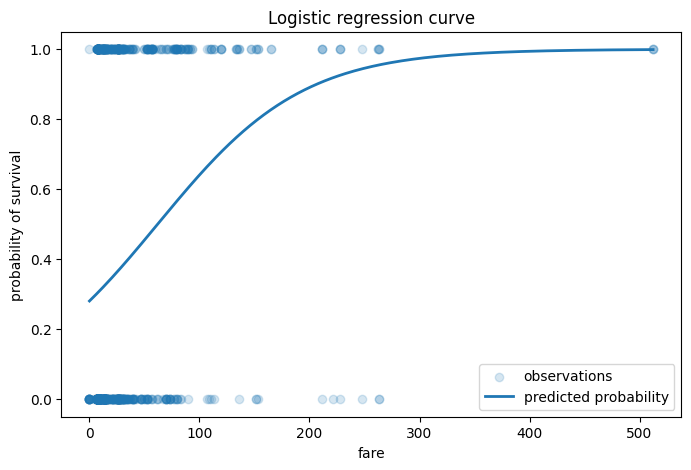

In [15]:
pred_df = pd.DataFrame({'fare': fare_grid})
pred_prob = model_1.predict(pred_df)

plt.figure(figsize=(8, 5))
plt.scatter(df['fare'], df['survived'], alpha=0.18, label='observations')
plt.plot(fare_grid, pred_prob, linewidth=2, label='predicted probability')
plt.xlabel('fare')
plt.ylabel('probability of survival')
plt.title('Logistic regression curve')
plt.legend()
plt.show()


## Part 4. The 50% separation point

A common classification rule is:

- predict class 1 if the predicted probability is greater than 0.5
- predict class 0 otherwise

With one predictor, we can compute the value where the probability is exactly 0.5.

For logistic regression:

$$\text{logit}(p) = \beta_0 + \beta_1 x$$

If $p = 0.5$, then $\text{logit}(0.5) = 0$.
So the boundary is:

$$x^* = -\frac{\beta_0}{\beta_1}$$

Here, $x^*$ is the estimated separation point in terms of `fare`.


In [16]:
b0 = model_1.params['Intercept']
b1 = model_1.params['fare']
fare_star = -b0 / b1
fare_star


np.float64(61.94236842271847)

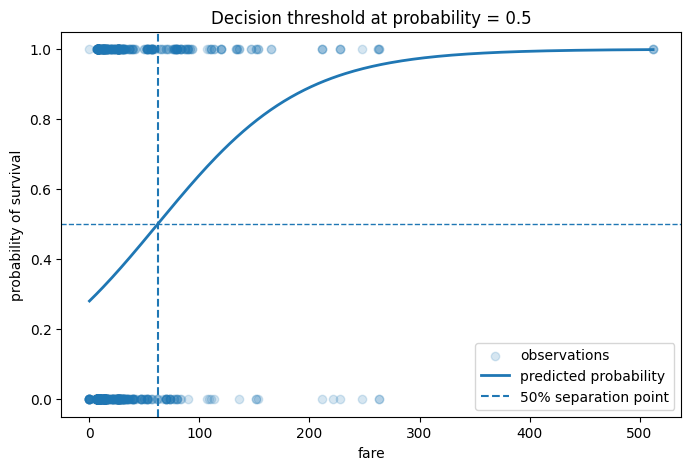

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df['fare'], df['survived'], alpha=0.18, label='observations')
plt.plot(fare_grid, pred_prob, linewidth=2, label='predicted probability')
plt.axhline(0.5, linestyle='--', linewidth=1)
plt.axvline(fare_star, linestyle='--', linewidth=1.5, label='50% separation point')
plt.xlabel('fare')
plt.ylabel('probability of survival')
plt.title('Decision threshold at probability = 0.5')
plt.legend()
plt.show()


## Part 5. Confidence interval for the logistic curve

A fitted model is estimated from a sample.
This means the curve is uncertain.

So we do not only want a fitted probability curve.
We also want a confidence interval around it.

This confidence band helps us answer a question like:

- how certain is the model about the predicted probability at each value of `fare`?

Usually, uncertainty is smaller where the data are dense and larger at the extremes.


In [18]:
pred_res = model_1.get_prediction(pred_df)
pred_frame = pred_res.summary_frame()
pred_frame.head()

,predicted,se,ci_lower,ci_upper
0,0.280632,0.019205,0.244569,0.319761
1,0.286987,0.018862,0.251482,0.325327
2,0.293428,0.018526,0.258471,0.331002
3,0.299952,0.018203,0.265527,0.336794
4,0.306559,0.017897,0.272641,0.342708


In [19]:
# Depending on the statsmodels version, summary_frame can differ.
# This block makes the notebook more robust.

cols = pred_frame.columns.tolist()
print(cols)

if 'mean' in pred_frame.columns and 'mean_ci_lower' in pred_frame.columns:
    mean_prob = pred_frame['mean'].to_numpy()
    lower_prob = pred_frame['mean_ci_lower'].to_numpy()
    upper_prob = pred_frame['mean_ci_upper'].to_numpy()
elif 'predicted' in pred_frame.columns and 'ci_lower' in pred_frame.columns:
    lin_mean = pred_frame['predicted'].to_numpy()
    lin_low = pred_frame['ci_lower'].to_numpy()
    lin_up = pred_frame['ci_upper'].to_numpy()
    mean_prob = expit(lin_mean)
    lower_prob = expit(lin_low)
    upper_prob = expit(lin_up)
else:
    # Fallback: use manual simulation from the covariance matrix
    params = model_1.params[['Intercept', 'fare']].to_numpy()
    cov = model_1.cov_params().loc[['Intercept', 'fare'], ['Intercept', 'fare']].to_numpy()
    draws = np.random.multivariate_normal(params, cov, size=3000)
    Xg = np.column_stack([np.ones(len(fare_grid)), fare_grid])
    eta_draws = draws @ Xg.T
    prob_draws = expit(eta_draws)
    mean_prob = prob_draws.mean(axis=0)
    lower_prob = np.percentile(prob_draws, 2.5, axis=0)
    upper_prob = np.percentile(prob_draws, 97.5, axis=0)


['predicted', 'se', 'ci_lower', 'ci_upper']


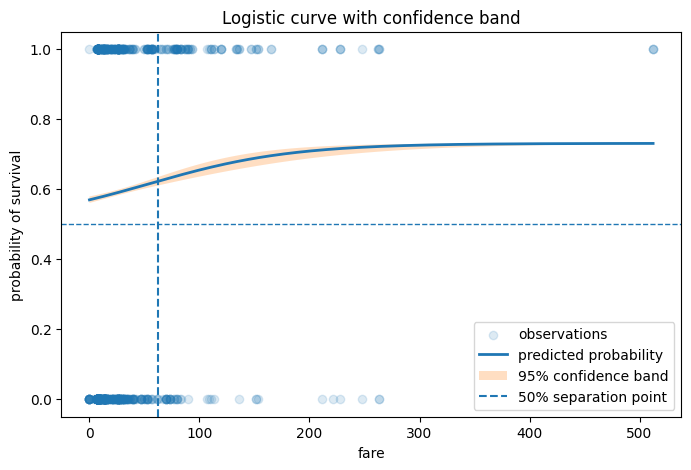

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df['fare'], df['survived'], alpha=0.15, label='observations')
plt.plot(fare_grid, mean_prob, linewidth=2, label='predicted probability')
plt.fill_between(fare_grid, lower_prob, upper_prob, alpha=0.25, label='95% confidence band')
plt.axhline(0.5, linestyle='--', linewidth=1)
plt.axvline(fare_star, linestyle='--', linewidth=1.5, label='50% separation point')
plt.xlabel('fare')
plt.ylabel('probability of survival')
plt.title('Logistic curve with confidence band')
plt.legend()
plt.show()


## Part 6. Confidence interval for the separation point

The separation point depends on the estimated coefficients.
So it is also uncertain.

Instead of deriving the formula by hand, we use a simulation approach:

1. sample many coefficient vectors from the estimated covariance matrix
2. compute the separation point for each sampled vector
3. use percentiles to get an approximate 95% confidence interval

This is intuitive and useful for teaching.


In [21]:
coef_mean = model_1.params[['Intercept', 'fare']].to_numpy()
coef_cov = model_1.cov_params().loc[['Intercept', 'fare'], ['Intercept', 'fare']].to_numpy()

draws = np.random.multivariate_normal(coef_mean, coef_cov, size=5000)
valid = np.abs(draws[:, 1]) > 1e-8
boundary_draws = -draws[valid, 0] / draws[valid, 1]

ci_low, ci_high = np.percentile(boundary_draws, [2.5, 97.5])
fare_star, ci_low, ci_high


(np.float64(61.94236842271847),
 np.float64(50.64765880825604),
 np.float64(79.11819005685258))

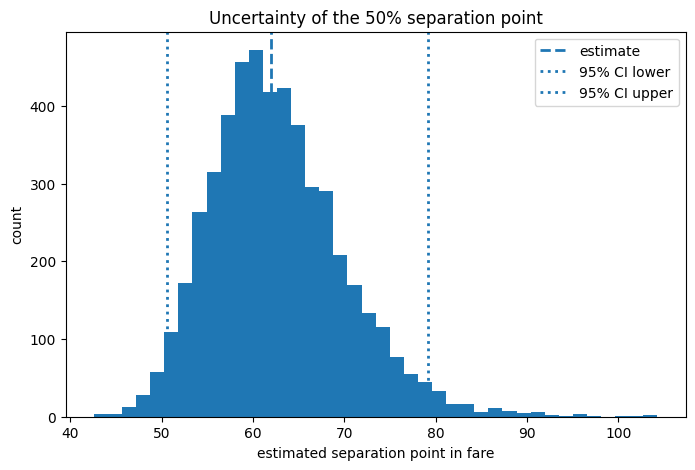

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(boundary_draws, bins=40)
plt.axvline(fare_star, linestyle='--', linewidth=2, label='estimate')
plt.axvline(ci_low, linestyle=':', linewidth=2, label='95% CI lower')
plt.axvline(ci_high, linestyle=':', linewidth=2, label='95% CI upper')
plt.xlabel('estimated separation point in fare')
plt.ylabel('count')
plt.title('Uncertainty of the 50% separation point')
plt.legend()
plt.show()


## Part 7. Logistic regression with multiple predictors

Now we move from a one-variable model to a more realistic model:

$$\text{survived} \sim \text{fare} + \text{age} + \text{family\_size}$$

This lets us study the effect of each variable while holding the others fixed.


In [23]:
df['family_size'] = df['sibsp'] + df['parch'] + 1 # number of siblings/spouses + number of parents/children + self

In [24]:
model_2 = smf.logit('survived ~ fare + age + family_size', data=df).fit()
print(model_2.summary())


Optimization terminated successfully.
         Current function value: 0.620807
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.08087
Time:                        10:37:13   Log-Likelihood:                -443.26
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 8.227e-17
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.0664      0.246     -0.269      0.788      -0.549       0.416
fare            0.0192    

In [26]:
np.exp(model_2.params)


Intercept      0.935790
fare           1.019404
age            0.977602
family_size    0.875356
dtype: float64

> We can't consider the effect of family_size because if we set the p_value threshold at 0.01, then family_size is not statistically significant.

### Interpretation

In the multiple-predictor model:

- the coefficient of `fare` measures the effect of fare while keeping age and family size fixed
- the coefficient of `age` measures the effect of age while keeping the other variables fixed
- the coefficient of `family_size` measures the effect of family size while keeping the other variables fixed

This is one of the main strengths of regression models.

However, this interpretation becomes harder when predictors are strongly correlated.
That is where multicollinearity becomes important.

## Part 8. What is multicollinearity?

Multicollinearity means that two or more predictors carry very similar information.

For example:
- `fare` may reflect ticket price
- `class_score` may also reflect social class or cabin quality

If these variables are strongly correlated, the model may have trouble deciding how to split the effect between them.

This can lead to:
- unstable coefficients
- large standard errors
- confusing p-values
- difficult interpretation

Prediction may still look acceptable, but interpretation becomes weaker.


## Part 9. VIF: Variance Inflation Factor

A standard diagnostic for multicollinearity is the Variance Inflation Factor, or VIF.

For a predictor $X_j$, the VIF is:

$$VIF_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is obtained by regressing $X_j$ on all the other predictors.

Interpretation:
- if $R_j^2$ is high, then $X_j$ is well explained by the other predictors
- this means $X_j$ is redundant
- as a consequence, the variance of its estimated regression coefficient is inflated

Rules of thumb:
- VIF close to 1: no strong multicollinearity
- VIF above 5: possible issue
- VIF above 10: serious issue

These are only rules of thumb, not strict laws.


In [27]:
df[['fare', 'pclass', 'age', 'family_size']].corr()


,fare,pclass,age,family_size
fare,1.000000,-0.549500,0.096067,0.217138
pclass,-0.549500,1.000000,-0.369226,0.065997
age,0.096067,-0.369226,1.000000,-0.301914
family_size,0.217138,0.065997,-0.301914,1.000000


In [28]:

X_vif = df[['fare', 'age', 'family_size', 'pclass']].copy()
X_vif['age'] = X_vif['age'].fillna(X_vif['age'].mean()) # fill missing age with mean for VIF calculation
X_vif=X_vif-X_vif.mean()/X_vif.std() # standardize features for better numerical stability in VIF calculation
vif_table = pd.DataFrame()
vif_table['feature'] = X_vif.columns
vif_table['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_table.sort_values('VIF', ascending=False)


,feature,VIF
0,fare,2.174271
3,pclass,2.096292
1,age,1.573363
2,family_size,1.240249


In [29]:
X_vif.dtypes

fare           float64
age            float64
family_size    float64
pclass         float64
dtype: object

### How to read the VIF table

You will probably see that `fare` and `class_score` have large VIF values.
This is expected, because we constructed them to be strongly correlated.

This does not necessarily mean the model is wrong.
It means that interpretation of the coefficients may become unstable.

A useful practical question is:

- do we really need both variables in the same model?


## Part 10. Fit a model with a collinear predictor

Now we include `class_score` together with `fare`.
Since these variables are strongly correlated, this is a good example of multicollinearity.


In [30]:
model_3 = smf.logit('survived ~ fare + age + family_size + pclass', data=df).fit()
print(model_3.summary())


Optimization terminated successfully.
         Current function value: 0.577546
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      709
Method:                           MLE   Df Model:                            4
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1449
Time:                        10:51:34   Log-Likelihood:                -412.37
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 3.144e-29
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.2748      0.509      6.438      0.000       2.278       4.272
fare            0.0038    

<Axes: xlabel='pclass', ylabel='fare'>

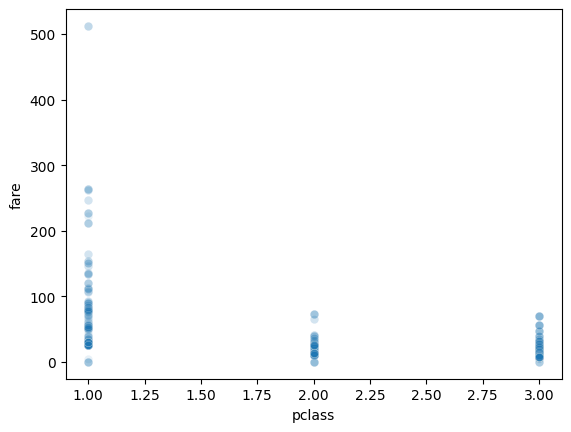

In [35]:
sns.scatterplot(df,x='pclass',y='fare',alpha=0.1)

### Compare `model_2` and `model_3`

Things to look at:

- Did the coefficients of `fare` or `class_score` become unstable?
- Did the standard errors increase?
- Did some p-values become less convincing?

This is a typical symptom of multicollinearity.


In [53]:
comparison = pd.DataFrame({
    'model_2_coef': model_2.params,
    'model_2_se': model_2.bse,
    'model_3_coef': model_3.params.reindex(model_2.params.index),
    'model_3_se': model_3.bse.reindex(model_2.params.index)
})
comparison


,model_2_coef,model_2_se,model_3_coef,model_3_se
Intercept,-0.066364,0.246281,3.274833,0.508693
fare,0.019218,0.002868,0.003751,0.002530
age,-0.022653,0.006205,-0.042099,0.007124
family_size,-0.133124,0.061806,-0.044255,0.063744


## Part 11. Remove one redundant predictor

A common practical choice is to remove one of two strongly correlated predictors.

This does not always improve prediction a lot.
But it often improves interpretability.

Here we fit a model that keeps `class_score` but removes `fare`.


In [55]:
model_4 = smf.logit('survived ~ age + family_size + pclass', data=df).fit()
print(model_4.summary())


Optimization terminated successfully.
         Current function value: 0.579391
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.1422
Time:                        20:13:54   Log-Likelihood:                -413.69
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 1.559e-29
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.6349      0.456      7.975      0.000       2.742       4.528
age            -0.0426    

### Discussion

After checking VIF and comparing models, you can ask:

- which model is easier to interpret?
- which variables are stable across models?
- are there variables that become significant only because of correlation patterns?

This is why VIF is useful.
It does not directly tell you which variable to remove.
But it tells you when interpretation needs care.


## Final Remarks

Before interpreting a model, always ask:

> Does the model actually explain the data?

In our simple model (survived ~ fare):

- The effect is statistically significant  
- But the overall fit is weak (very low Pseudo R²)  

This means:

> The model captures a signal, but it is not strong enough to support meaningful conclusions.

### Rule of thumb

- Statistical significance is not enough  
- A model must also have reasonable predictive power  
- If the model is too weak, interpretation is unreliable  

### Practical implication

If your model:

- has very low Pseudo R² (e.g. < 0.1)
- or does not predict well  

→ do NOT over-interpret the coefficients  

Instead:

- improve the model (add relevant variables)  
- then interpret the results  